In [ ]:
import pandas as pd

In [ ]:
hd = pd.read_csv('/content/dataset.csv')
print(hd.head())

   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   40    1                2           140          289                    0   
1   49    0                3           160          180                    0   
2   37    1                2           130          283                    0   
3   48    0                4           138          214                    0   
4   54    1                3           150          195                    0   

   resting ecg  max heart rate  exercise angina  oldpeak  ST slope  target  
0            0             172                0      0.0         1       0  
1            0             156                0      1.0         2       1  
2            1              98                0      0.0         1       0  
3            0             108                1      1.5         2       1  
4            0             122                0      0.0         1       0  


In [ ]:
hd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [ ]:
hd.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [ ]:
hd.nunique().value_counts()

,count
2,4
4,2
50,1
67,1
222,1
3,1
119,1
53,1


### Data Scaling

Next, we'll scale numerical features using `StandardScaler` to normalize their ranges. This is crucial for many machine learning algorithms.

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Define the columns to be scaled
scaling_col_names = ['resting bp s','cholesterol','max heart rate','oldpeak']

# Create a StandardScaler instance
scaler = StandardScaler()

# Fit the scaler and transform the selected columns from the original DataFrame `hd`
scaled_data = scaler.fit_transform(hd[scaling_col_names])

# Create a DataFrame from the scaled data, retaining original column names and index
scaled_df = pd.DataFrame(scaled_data, columns=scaling_col_names, index=hd.index)

# Replace the original columns in `hd` with their scaled counterparts
hd[scaling_col_names] = scaled_df

# Print the head of the DataFrame to show the scaled columns
print('Dataset with Scaled columns data : \n', hd.head())

Dataset with Scaled columns data : 
    age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   40    1                2      0.427328     0.775674                    0   
1   49    0                3      1.516587    -0.299512                    0   
2   37    1                2     -0.117301     0.716489                    0   
3   48    0                4      0.318402     0.035867                    0   
4   54    1                3      0.971958    -0.151550                    0   

   resting ecg  max heart rate  exercise angina   oldpeak  ST slope  target  
0            0        1.265039                0 -0.849792         1       0  
1            0        0.637758                0  0.071119         2       1  
2            1       -1.636136                0 -0.849792         1       0  
3            0       -1.244085                1  0.531575         2       1  
4            0       -0.695214                0 -0.849792         1       0  


### Visualize Feature Distributions

Now, let's visualize the distribution of each feature, differentiating by the `target` variable, to understand their characteristics and relationship with heart disease.

/tmp/ipykernel_155/572080485.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


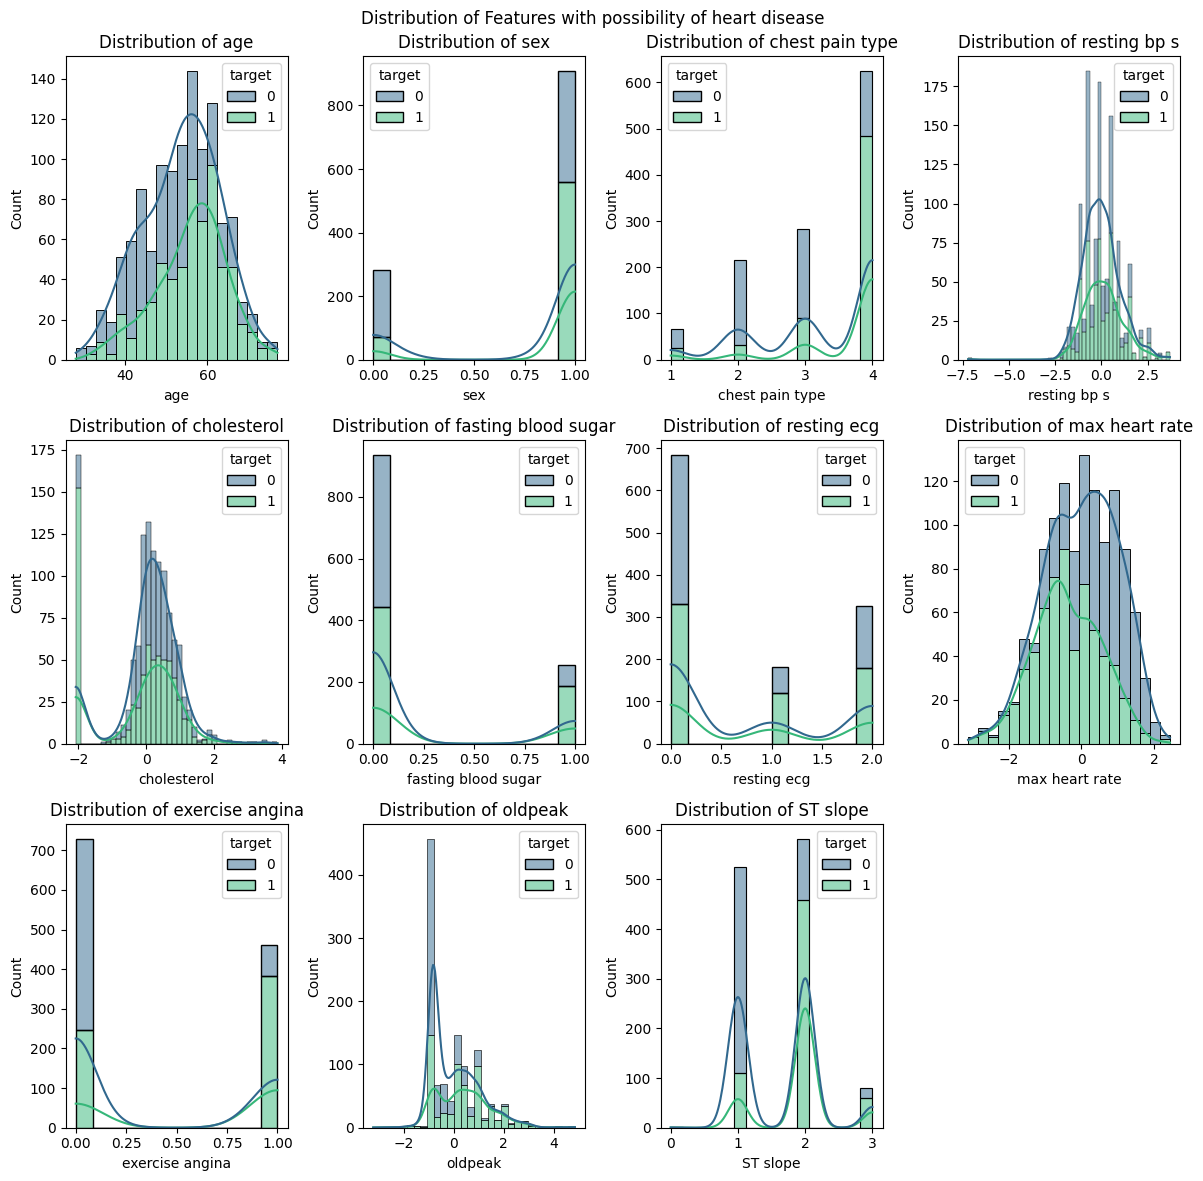

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

features = [col for col in hd.columns if col != 'target']
feature_len = len(features)

n_cols = 4
n_rows = math.ceil(feature_len / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_rows * 4, n_cols * 3), constrained_layout = True)
axes = axes.flatten()

for i, feature in enumerate(features):
  sns.histplot(data = hd, x = feature, hue = 'target', ax = axes[i], multiple = 'stack', kde = True, palette = 'viridis' )
  axes[i].set_title(f'Distribution of {feature}')
  axes[i].set_xlabel(feature)
  axes[i].set_ylabel('Count')

for y in range(i + 1, len(axes)):
  fig.delaxes(axes[y])

plt.suptitle('Distribution of Features with possibility of heart disease ')
plt.tight_layout()
plt.show()

### Correlation Heatmap

Let's analyze the correlation matrix of all features to identify relationships between variables, including their correlation with the target variable.

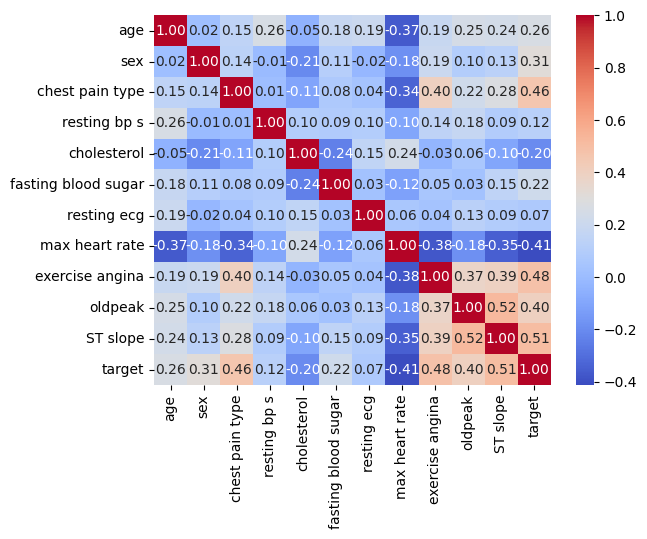

In [ ]:
sns.heatmap(hd.corr(), annot=True, fmt = '.2f', cmap='coolwarm')
plt.show()

### Outlier Detection for 'resting bp s'

We'll calculate the Interquartile Range (IQR) to identify potential outliers in the 'resting bp s' column, a common method for outlier detection.

In [ ]:
Q1_bp = hd['resting bp s'].quantile(0.25)
Q3_bp = hd['resting bp s'].quantile(0.75)
IQR_bp = Q3_bp - Q1_bp

upper_bound_bp = Q3_bp + 1.5 * IQR_bp
lower_bound_bp = Q1_bp - 1.5 * IQR_bp

print('Maximum resting bp s :', hd['resting bp s'].max())
print('Minimum resting bp s :', hd['resting bp s'].min())
print('IQR Value of resting bp s:', IQR_bp)
print("Upper Bound for 'resting bp s':", upper_bound_bp)
print("Lower Bound for 'resting bp s':", lower_bound_bp)


Maximum resting bp s : 3.6951056551911075
Minimum resting bp s : -7.197485671406159
IQR Value of resting bp s: 1.0892591326597267
Upper Bound for 'resting bp s': 2.0612169562015175
Lower Bound for 'resting bp s': -2.295819574437389


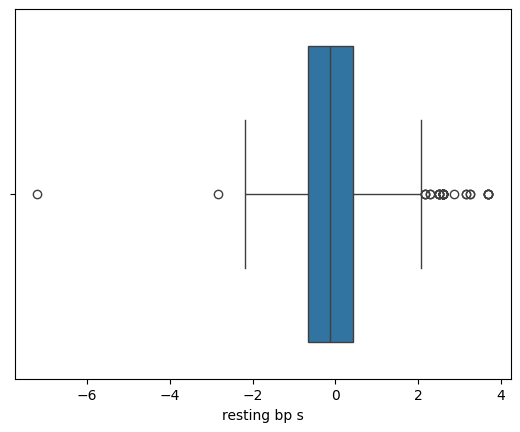

In [ ]:
sns.boxplot(x = hd['resting bp s'])
plt.show()

##Outlier Handling

###1. Winsorization (Capping)

Statistics for resting bp s after Winsorization:


,resting bp s
count,1190.000000
mean,-0.016156
std,0.923419
min,-2.295820
25%,-0.661931
50%,-0.117301
75%,0.427328
max,2.061217


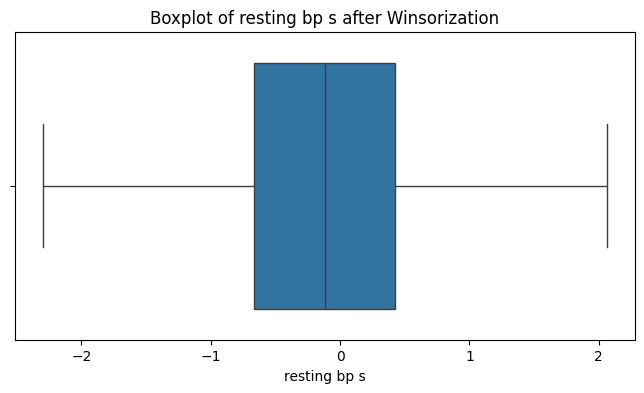

In [ ]:
import numpy as np

# Create a copy of the DataFrame to apply Winsorization
hd_winsorized = hd.copy()

# Apply Winsorization (capping) to 'resting bp s'
hd_winsorized['resting bp s'] = np.clip(hd_winsorized['resting bp s'], lower_bound_bp, upper_bound_bp)

print('Statistics for resting bp s after Winsorization:')
display(hd_winsorized['resting bp s'].describe())

# Visualize the effect of Winsorization with a boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=hd_winsorized['resting bp s'])
plt.title('Boxplot of resting bp s after Winsorization')
plt.show()

### 2. Transformation (using PowerTransformer)

Statistics for resting bp s after Transformation:


,resting bp s
count,1.190000e+03
mean,5.970947e-18
std,1.000420e+00
min,-8.901799e+00
25%,-6.435849e-01
50%,-6.820546e-02
75%,4.691851e-01
max,3.278290e+00


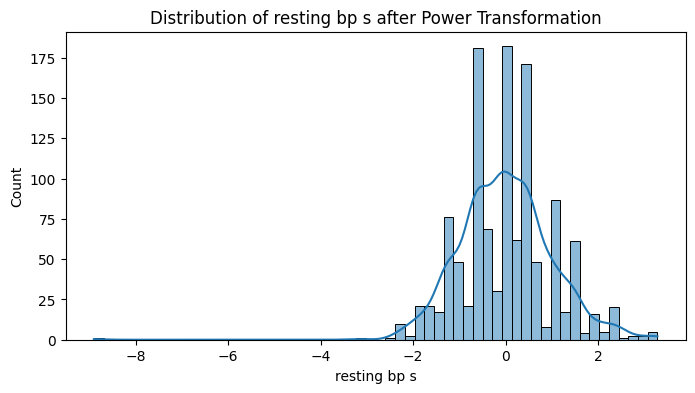

In [ ]:
from sklearn.preprocessing import PowerTransformer

# Create a copy of the DataFrame to apply transformation
hd_transformed = hd.copy()

# Initialize PowerTransformer (Yeo-Johnson can handle positive and negative values)
pt = PowerTransformer(method='yeo-johnson')

# Fit and transform the 'resting bp s' column
# Reshape for PowerTransformer which expects a 2D array
hd_transformed['resting bp s'] = pt.fit_transform(hd_transformed[['resting bp s']])

print('Statistics for resting bp s after Transformation:')
display(hd_transformed['resting bp s'].describe())

# Visualize the effect of transformation with a histogram
plt.figure(figsize=(8, 4))
sns.histplot(hd_transformed['resting bp s'], kde=True)
plt.title('Distribution of resting bp s after Power Transformation')
plt.show()


### Transformation for 'cholesterol'

Applying a Power Transformation (Yeo-Johnson) to the 'cholesterol' column to achieve a more Gaussian-like distribution, which can benefit some models.

Statistics for cholesterol after Transformation:


,cholesterol
count,1.190000e+03
mean,9.553516e-17
std,1.000420e+00
min,-1.823542e+00
25%,-3.550365e-01
50%,6.754728e-02
75%,5.455582e-01
max,5.869820e+00


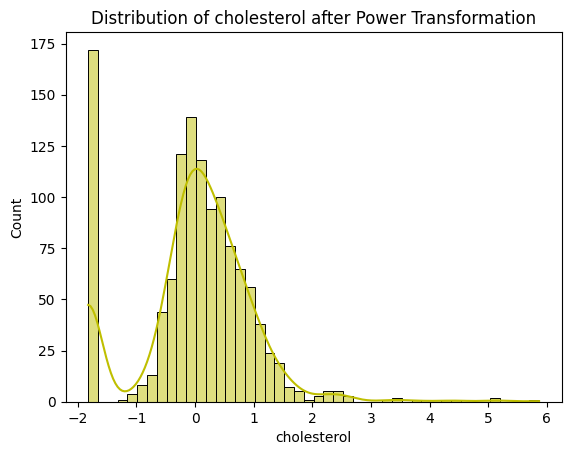

In [ ]:
hd_transformed['cholesterol'] = pt.fit_transform(hd_transformed[['cholesterol']])
print('Statistics for cholesterol after Transformation:')
display(hd_transformed['cholesterol'].describe())

# Visualize the effect of transformation with a histogram
sns.histplot(hd_transformed['cholesterol'], kde=True, color = 'y')
plt.title('Distribution of cholesterol after Power Transformation')
plt.show()

### Transformation for 'oldpeak'

Similarly, we'll apply a Power Transformation to the 'oldpeak' column to normalize its distribution.

Statistics of oldpeak after Transformation :


,oldpeak
count,1.190000e+03
mean,4.776758e-17
std,1.000420e+00
min,-6.537257e+00
25%,-9.342328e-01
50%,-1.105527e-01
75%,8.174556e-01
max,2.819265e+00


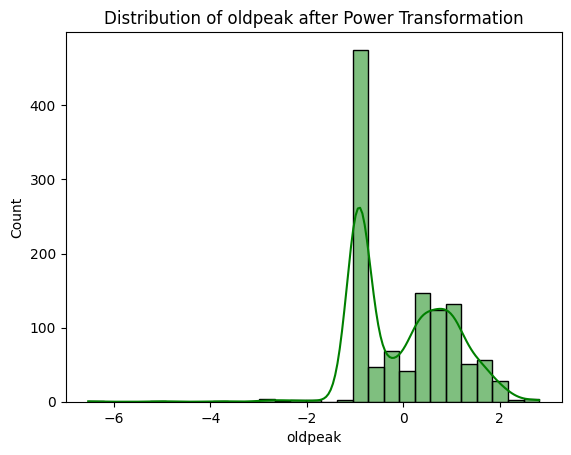

In [ ]:
hd_transformed['oldpeak'] = pt.fit_transform(hd_transformed[['oldpeak']])
print('Statistics of oldpeak after Transformation :')
display(hd_transformed['oldpeak'].describe())

sns.histplot(hd_transformed['oldpeak'], kde = True, color = 'g')
plt.title('Distribution of oldpeak after Power Transformation')
plt.show()

### Transformed Data Overview

Let's display the head of the `hd_transformed` DataFrame to see the effect of the transformations on the selected columns.

In [ ]:
display(hd_transformed.head())

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,0.469185,0.775674,0,0,1.265039,0,-0.849792,1,0
1,49,0,3,1.462290,-0.299512,0,0,0.637758,0,0.071119,2,1
2,37,1,2,-0.068205,0.716489,0,1,-1.636136,0,-0.849792,1,0
3,48,0,4,0.364591,0.035867,0,0,-1.244085,1,0.531575,2,1
4,54,1,3,0.976111,-0.151550,0,0,-0.695214,0,-0.849792,1,0


### Model Training and Evaluation (LightGBM)

Finally, we'll train a LightGBM classifier on the preprocessed data, split into training and testing sets, and evaluate its performance using various metrics.

In [ ]:
import lightgbm as lgbm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, r2_score, confusion_matrix, classification_report

X = hd_transformed.drop('target', axis = 1)
y = hd_transformed['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

lgbm_model = lgbm.LGBMClassifier(random_state = 42)
lgbm_model.fit(X_train, y_train)

y_pred = lgbm_model.predict(X_test)

print('\nAccuracy :', accuracy_score(y_test, y_pred))
print('\nPrecision :', precision_score(y_test, y_pred))
print('\nR2 Score :', r2_score(y_test, y_pred))
print('\nConfusion Matrix :\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report :\n', classification_report(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 498, number of negative: 454
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 399
[LightGBM] [Info] Number of data points in the train set: 952, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.523109 -> initscore=0.092503
[LightGBM] [Info] Start training from score 0.092503

Accuracy : 0.9537815126050421

Precision : 0.9545454545454546

R2 Score : 0.813226796033388

Confusion Matrix :
 [[101   6]
 [  5 126]]

Classification Report :
               precision    recall  f1-score   support

           0       0.95      0.94      0.95       107
           1       0.95      0.96      0.96       131

    accuracy                           0.95 

### Summary of Findings

**1. Data Loading and Initial Inspection:**
- A dataset was loaded from `/content/dataset.csv` into a Pandas DataFrame `hd`.
- Initial inspection revealed 1190 entries and 12 columns, primarily integer types, with one float column (`oldpeak`).
- Basic descriptive statistics provided insights into the range, mean, and standard deviation of each feature.

**2. Data Scaling:**
- Numerical features (`resting bp s`, `cholesterol`, `max heart rate`, `oldpeak`) were scaled using `StandardScaler` to normalize their ranges, which is crucial for many machine learning algorithms.

**3. Feature Distributions:**
- Histograms were generated to visualize the distribution of each feature, differentiated by the `target` variable. This helped in understanding individual feature characteristics and their preliminary relationship with heart disease.

**4. Correlation Heatmap:**
- A correlation heatmap was generated to identify relationships between all variables, including their correlation with the `target` variable. This helps in understanding multicollinearity and feature importance.

**5. Outlier Detection and Handling for 'resting bp s':**
- **Outlier Detection:** The Interquartile Range (IQR) method was used to identify potential outliers in the 'resting bp s' column, establishing upper and lower bounds.
- **Outlier Handling Methods Explored:**
    - **Winsorization (Capping):** Outliers in 'resting bp s' were capped at the calculated upper and lower bounds, effectively reducing their extreme values while retaining other data points. A boxplot confirmed the removal of extreme outliers.
    - **Transformation (PowerTransformer):** The 'resting bp s' column was transformed using `PowerTransformer` (Yeo-Johnson method) to achieve a more Gaussian-like distribution. This method was also applied to 'cholesterol' and 'oldpeak' to normalize their distributions.

**6. Model Training and Evaluation (LightGBM):**
- A LightGBM classifier was trained on the preprocessed `hd_transformed` dataset.
- The data was split into training (80%) and testing (20%) sets.
- The model's performance was evaluated using various metrics on the test set, yielding:
    - **Accuracy:** 0.9538
    - **Precision:** 0.9545
    - **R2 Score:** 0.8132
    - **Confusion Matrix:** `[[101 6] [ 5 126]]`
    - **Classification Report:** Showed strong precision, recall, and f1-scores for both classes (0 and 1), indicating a highly effective model with a balanced performance across categories.

In conclusion, the analysis involved comprehensive data preprocessing steps, including scaling and outlier handling through Winsorization and Power Transformation, which led to a robust LightGBM model demonstrating excellent predictive performance on the heart disease dataset.